# SciFact BGE-small Cross-Model OPQ-IVF-PQ Benchmark

This notebook repeats the established SciFact benchmark using `BAAI/bge-small-en-v1.5` instead of MiniLM. It preserves the same PQ/OPQ/IVF settings and evaluation protocol for a like-for-like cross-model comparison.

**Important:** This is a benchmark-only notebook. It does not overwrite the deployed MiniLM FiQA OPQ FastAPI artifact.

# SciFact OPQ-IVF-PQ Cross-Dataset Benchmark

Independent SciFact / BEIR validation for the FiQA RAG embedding-compression project. This notebook evaluates ranking and compression trade-offs only; it does not export or overwrite the deployed FiQA FastAPI artifact.

In [1]:
%pip uninstall -y faiss-cpu faiss-gpu faiss-gpu-cu11 faiss-gpu-cu12
%pip install -q --upgrade --upgrade-strategy only-if-needed \
  "transformers==4.49.0" \
  "sentence-transformers==3.4.1" \
  "tokenizers>=0.21,<0.22" \
  "sentencepiece>=0.2.0" \
  "safetensors>=0.4.5" \
  "faiss-gpu-cu12>=1.10.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 14.6 MB/s eta 0:00:00


In [2]:
# 1. Imports, CUDA validation, and reproducibility

import os
import gc
import csv
import json
import math
import time
import random
import zipfile
import urllib.request
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss

import torch
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU is required. In Colab: Runtime > Change runtime type > T4 GPU."
    )

DEVICE = torch.device("cuda")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)
print("Faiss:", faiss.__version__)
print("FAISS visible GPUs:", faiss.get_num_gpus())
if faiss.get_num_gpus() < 1:
    raise RuntimeError(
        "CUDA PyTorch is available, but this FAISS build has no GPU backend. "
        "Restart the Colab runtime after installing faiss-gpu-cu12, then re-run from Cell 1."
    )


GPU: Tesla T4
CUDA: 12.8
Faiss: 1.14.1
FAISS visible GPUs: 1


In [3]:
# 2. Experiment configuration — SciFact / BEIR

DATASET_NAME = "scifact"
DATASET_DISPLAY_NAME = "SciFact (BEIR)"
DATASET_URL = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/scifact.zip"

DATA_DIR = Path("beir_data")
DATASET_DIR = DATA_DIR / DATASET_NAME

EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
DOC_EMBED_BATCH_SIZE = 256
QUERY_EMBED_BATCH_SIZE = 256

MAX_DOCS = None
MAX_QUERIES = None

RETRIEVAL_K_VALUES = [5, 10]
RANKING_K = max(RETRIEVAL_K_VALUES + [10])

KMEANS_TRAIN_POINTS = 24_000
KMEANS_BATCH_SIZE = 4096
KMEANS_MAX_ITER = 30
KMEANS_TOL = 1e-4

PQ_SETTINGS = [
    (24, 256),
    (48, 256),
    (64, 256),
    (96, 256),
]
OPQ_SETTINGS = [
    (24, 8),
    (48, 8),
    (64, 8),
    (96, 8),
]
OPQ_OUTER_ITERS = 6
OPQ_PQ_INNER_ITERS = 18

RESULT_DIR = Path(f"{DATASET_NAME}_bge_small_rag_results")
RESULT_DIR.mkdir(exist_ok=True, parents=True)

print("Dataset:", DATASET_DISPLAY_NAME)
print("Model:", EMBEDDING_MODEL)
print("PQ:", PQ_SETTINGS)
print("OPQ:", OPQ_SETTINGS)


Dataset: SciFact (BEIR)
Model: sentence-transformers/all-MiniLM-L6-v2
PQ: [(24, 256), (48, 256), (64, 256), (96, 256)]
OPQ: [(24, 8), (48, 8), (64, 8), (96, 8)]


In [4]:
# 3. Download and parse SciFact corpus, queries, and qrels

def download_and_extract_dataset():
    DATA_DIR.mkdir(exist_ok=True, parents=True)
    zip_path = DATA_DIR / f"{DATASET_NAME}.zip"

    if not DATASET_DIR.exists():
        if not zip_path.exists():
            print(f"Downloading {DATASET_DISPLAY_NAME} archive...")
            urllib.request.urlretrieve(DATASET_URL, zip_path)

        print(f"Extracting {DATASET_DISPLAY_NAME} archive...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(DATA_DIR)

    required = [
        DATASET_DIR / "corpus.jsonl",
        DATASET_DIR / "queries.jsonl",
        DATASET_DIR / "qrels" / "test.tsv",
    ]
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(
            f"{DATASET_DISPLAY_NAME} extraction incomplete. Missing: {missing}"
        )


def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as file:
        for line in file:
            rows.append(json.loads(line))
    return rows


def read_qrels(path):
    qrels = {}
    with open(path, "r", encoding="utf-8") as file:
        reader = csv.DictReader(file, delimiter="\t")
        for row in reader:
            qid = str(row["query-id"])
            docid = str(row["corpus-id"])
            score = int(row["score"])
            qrels.setdefault(qid, {})[docid] = score
    return qrels


download_and_extract_dataset()

corpus_rows = read_jsonl(DATASET_DIR / "corpus.jsonl")
query_rows = read_jsonl(DATASET_DIR / "queries.jsonl")
all_qrels = read_qrels(DATASET_DIR / "qrels" / "test.tsv")

if MAX_DOCS is not None:
    corpus_rows = corpus_rows[:MAX_DOCS]

doc_ids = [str(row["_id"]) for row in corpus_rows]
doc_texts = [
    ((row.get("title") or "") + "\n" + (row.get("text") or "")).strip()
    for row in corpus_rows
]
doc_id_to_index = {doc_id: index for index, doc_id in enumerate(doc_ids)}

query_ids, query_texts, qrels = [], [], {}

for row in query_rows:
    qid = str(row["_id"])

    if qid not in all_qrels:
        continue

    filtered = {
        doc_id: score
        for doc_id, score in all_qrels[qid].items()
        if doc_id in doc_id_to_index and score > 0
    }

    if filtered:
        query_ids.append(qid)
        query_texts.append(str(row["text"]))
        qrels[qid] = filtered

if MAX_QUERIES is not None:
    query_ids = query_ids[:MAX_QUERIES]
    query_texts = query_texts[:MAX_QUERIES]
    qrels = {qid: qrels[qid] for qid in query_ids}

print(f"Documents retained: {len(doc_ids):,}")
print(f"Evaluation queries: {len(query_ids):,}")
print(f"Queries with qrels: {len(qrels):,}")
print("Example query:", query_texts[0])


Extracting SciFact (BEIR) archive...
Documents retained: 5,183
Evaluation queries: 300
Queries with qrels: 300
Example query: 0-dimensional biomaterials show inductive properties.


In [5]:
# 4. GPU embedding generation

def encode_texts_gpu(texts, model_name, batch_size):
    model = SentenceTransformer(model_name, device="cuda")
    vectors = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
        device="cuda",
    )
    del model
    torch.cuda.empty_cache()
    return torch.from_numpy(vectors.astype(np.float32)).to(DEVICE)

print("Encoding SciFact documents on GPU...")
X_docs = encode_texts_gpu(doc_texts, EMBEDDING_MODEL, DOC_EMBED_BATCH_SIZE)

print("Encoding SciFact queries on GPU...")
X_queries = encode_texts_gpu(query_texts, EMBEDDING_MODEL, QUERY_EMBED_BATCH_SIZE)

N_DOCS, D = X_docs.shape
N_QUERIES = X_queries.shape[0]

print("Document embedding matrix:", tuple(X_docs.shape))
print("Query embedding matrix:", tuple(X_queries.shape))

Encoding FiQA documents on GPU...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Encoding FiQA queries on GPU...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Document embedding matrix: (5183, 384)
Query embedding matrix: (300, 384)


## Retrieval metrics

- **Recall@K**: proportion of judged-relevant documents recovered among all relevant documents for a query.
- **MRR@10**: reciprocal rank of the first relevant document, capped at rank 10.
- **nDCG@10**: ranked relevance with BEIR qrels scores.
- Queries remain float32. Only stored document embeddings are compressed.

In [6]:
# 5. Retrieval, relevance, and latency helpers

def normalize(x, eps=1e-12):
    return F.normalize(x, p=2, dim=1, eps=eps)

@torch.no_grad()
def gpu_topk(x_queries, x_docs, k, batch_size=128):
    x_queries = normalize(x_queries)
    x_docs = normalize(x_docs)
    outputs = []

    torch.cuda.synchronize()
    start_time = time.perf_counter()

    for start in range(0, x_queries.shape[0], batch_size):
        scores = x_queries[start:start + batch_size] @ x_docs.T
        outputs.append(torch.topk(scores, k=k, dim=1, largest=True).indices)

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - start_time
    return torch.cat(outputs, dim=0), elapsed

def ranking_metrics(rankings, query_ids, doc_ids, qrels, k_values=(5, 10)):
    rankings_np = rankings.detach().cpu().numpy()
    metrics = {}

    for k in k_values:
        recalls = []
        for row, qid in zip(rankings_np[:, :k], query_ids):
            relevant = set(qrels[qid].keys())
            retrieved = {doc_ids[int(idx)] for idx in row}
            recalls.append(len(relevant & retrieved) / len(relevant))
        metrics[f"recall_at_{k}"] = float(np.mean(recalls))

    mrr_scores = []
    ndcg_scores = []

    for row, qid in zip(rankings_np[:, :10], query_ids):
        relevance_map = qrels[qid]
        gains = np.array([relevance_map.get(doc_ids[int(idx)], 0) for idx in row], dtype=np.float32)

        first_rel = np.where(gains > 0)[0]
        mrr_scores.append(1.0 / (first_rel[0] + 1) if len(first_rel) else 0.0)

        discounts = 1.0 / np.log2(np.arange(2, 12))
        dcg = np.sum((2**gains - 1) * discounts)

        ideal_gains = np.sort(np.array(list(relevance_map.values()), dtype=np.float32))[::-1][:10]
        ideal_discounts = 1.0 / np.log2(np.arange(2, len(ideal_gains) + 2))
        idcg = np.sum((2**ideal_gains - 1) * ideal_discounts)
        ndcg_scores.append(float(dcg / idcg) if idcg > 0 else 0.0)

    metrics["mrr_at_10"] = float(np.mean(mrr_scores))
    metrics["ndcg_at_10"] = float(np.mean(ndcg_scores))
    return metrics

ORIGINAL_RANKINGS, ORIGINAL_LATENCY = gpu_topk(X_queries, X_docs, RANKING_K)
ORIGINAL_METRICS = ranking_metrics(
    ORIGINAL_RANKINGS, query_ids, doc_ids, qrels, RETRIEVAL_K_VALUES
)

print("Float32 retrieval metrics:", ORIGINAL_METRICS)
print(f"Float32 retrieval latency: {ORIGINAL_LATENCY:.3f} seconds")

Float32 retrieval metrics: {'recall_at_5': 0.7379444444444444, 'recall_at_10': 0.7833333333333333, 'mrr_at_10': 0.6047248677248678, 'ndcg_at_10': 0.6450816521455776}
Float32 retrieval latency: 0.078 seconds


In [7]:
# 6. GPU quantizers: scalar, PQ, and learned OPQ-PQ

@dataclass
class PQModel:
    m: int
    k: int
    sub_dim: int
    codebooks: torch.Tensor  # [m, k, sub_dim]

def sample_training_points(x, max_points=KMEANS_TRAIN_POINTS, seed=SEED):
    if x.shape[0] <= max_points:
        return x
    gen = torch.Generator(device=DEVICE)
    gen.manual_seed(seed)
    idx = torch.randperm(x.shape[0], generator=gen, device=DEVICE)[:max_points]
    return x[idx]

@torch.no_grad()
def gpu_kmeans(x, k, max_iter=KMEANS_MAX_ITER, batch_size=KMEANS_BATCH_SIZE,
               tol=KMEANS_TOL, seed=SEED):
    x = x.contiguous()
    n, dim = x.shape
    if k > n:
        raise ValueError(f"k={k} exceeds available training vectors={n}")

    gen = torch.Generator(device=DEVICE)
    gen.manual_seed(seed)
    centers = x[torch.randperm(n, generator=gen, device=DEVICE)[:k]].clone()

    for _ in range(max_iter):
        sums = torch.zeros((k, dim), device=DEVICE, dtype=x.dtype)
        counts = torch.zeros((k,), device=DEVICE, dtype=x.dtype)

        for start in range(0, n, batch_size):
            batch = x[start:start + batch_size]
            distances = (
                (batch * batch).sum(dim=1, keepdim=True)
                + (centers * centers).sum(dim=1).unsqueeze(0)
                - 2.0 * (batch @ centers.T)
            )
            labels = distances.argmin(dim=1)
            sums.index_add_(0, labels, batch)
            counts.index_add_(0, labels, torch.ones_like(labels, dtype=x.dtype))

        updated = sums / counts.clamp_min(1.0).unsqueeze(1)
        empty = counts == 0
        if empty.any():
            refill = torch.randint(
                0, n, (int(empty.sum().item()),),
                generator=gen, device=DEVICE,
            )
            updated[empty] = x[refill]

        shift = torch.norm(updated - centers) / torch.norm(centers).clamp_min(1e-12)
        centers = updated
        if float(shift.item()) < tol:
            break

    return centers.contiguous()

@torch.no_grad()
def train_pq_gpu(x_train, m, k, max_iter=KMEANS_MAX_ITER):
    n, d = x_train.shape
    if d % m != 0:
        raise ValueError(f"Embedding dimension D={d} must be divisible by m={m}")

    sub_dim = d // m
    train_points = sample_training_points(x_train)
    codebooks = []

    for subspace in range(m):
        block = train_points[:, subspace * sub_dim:(subspace + 1) * sub_dim].contiguous()
        codebooks.append(
            gpu_kmeans(block, k, max_iter=max_iter, seed=SEED + subspace)
        )

    return PQModel(
        m=m,
        k=k,
        sub_dim=sub_dim,
        codebooks=torch.stack(codebooks).contiguous(),
    )

@torch.no_grad()
def pq_encode_decode(model, x, batch_size=KMEANS_BATCH_SIZE, normalize_output=True):
    n = x.shape[0]
    recon = torch.empty_like(x)
    codes = torch.empty((n, model.m), dtype=torch.int32, device=DEVICE)

    for subspace in range(model.m):
        start_dim = subspace * model.sub_dim
        end_dim = (subspace + 1) * model.sub_dim
        block = x[:, start_dim:end_dim]
        codebook = model.codebooks[subspace]

        all_codes, all_recon = [], []
        for start in range(0, n, batch_size):
            batch = block[start:start + batch_size]
            distances = (
                (batch * batch).sum(dim=1, keepdim=True)
                + (codebook * codebook).sum(dim=1).unsqueeze(0)
                - 2.0 * (batch @ codebook.T)
            )
            batch_codes = distances.argmin(dim=1)
            all_codes.append(batch_codes)
            all_recon.append(codebook[batch_codes])

        chosen = torch.cat(all_codes)
        codes[:, subspace] = chosen.to(torch.int32)
        recon[:, start_dim:end_dim] = torch.cat(all_recon)

    return codes, normalize(recon) if normalize_output else recon

@torch.no_grad()
def train_opq_pq_gpu(x_train, m, k, outer_iters, pq_inner_iters):
    # Learned orthogonal rotation through alternating PQ reconstruction and Procrustes updates.
    n, d = x_train.shape
    if d % m != 0:
        raise ValueError(f"D={d} must be divisible by m={m}")

    points = sample_training_points(x_train)
    rotation = torch.eye(d, device=DEVICE, dtype=torch.float32)

    for step in range(outer_iters):
        rotated = (points @ rotation).contiguous()
        pq_model = train_pq_gpu(rotated, m=m, k=k, max_iter=pq_inner_iters)
        _, reconstructed = pq_encode_decode(
            pq_model, rotated, normalize_output=False
        )

        covariance = points.T @ reconstructed
        u, _, vh = torch.linalg.svd(covariance, full_matrices=False)
        rotation = (u @ vh).contiguous()

        print(f"OPQ outer step {step + 1}/{outer_iters} complete.")

    final_pq = train_pq_gpu((x_train @ rotation).contiguous(), m=m, k=k)
    return rotation, final_pq

@torch.no_grad()
def opq_encode_decode(rotation, pq_model, x):
    rotated = (x @ rotation).contiguous()
    codes, reconstructed_rotated = pq_encode_decode(pq_model, rotated)
    return codes, normalize(reconstructed_rotated @ rotation.T)

In [8]:
# 7. Deployment storage accounting

def original_float32_bytes(n_docs, d):
    return int(n_docs * d * 4)

def dense_transform_bytes(d):
    return int(d * d * 4)

def scalar_storage(n_docs, d, bits):
    return {
        "payload_bytes": int(math.ceil(n_docs * d * bits / 8)),
        "codebook_or_scale_bytes": 4,  # float32 scale
        "transform_bytes": 0,
    }

def pq_storage(n_docs, d, m, k, transform_bytes=0):
    bits_per_subcode = int(math.ceil(math.log2(k)))
    return {
        "payload_bytes": int(math.ceil(n_docs * m * bits_per_subcode / 8)),
        "codebook_or_scale_bytes": int(k * d * 4),
        "transform_bytes": int(transform_bytes),
    }

def storage_row(method, storage):
    baseline = original_float32_bytes(N_DOCS, D)
    payload = storage["payload_bytes"]
    format_bytes = payload + storage["codebook_or_scale_bytes"]
    deployment_bytes = format_bytes + storage["transform_bytes"]

    return {
        "method": method,
        "stored_documents": N_DOCS,
        "original_float32_bytes": baseline,
        "payload_bytes": payload,
        "codebook_or_scale_bytes": storage["codebook_or_scale_bytes"],
        "transform_bytes": storage["transform_bytes"],
        "format_bytes": format_bytes,
        "deployment_bytes": deployment_bytes,
        "payload_ratio": baseline / payload,
        "format_ratio": baseline / format_bytes,
        "deployment_compression_ratio": baseline / deployment_bytes,
    }

In [9]:
# 8. Run SciFact RAG compression benchmark

results = []
compressed_doc_embeddings = {}
# Reused later by the GPU FAISS OPQ + IVF-PQ benchmark.
opq_rotations = {}

def evaluate_method(method, X_docs_hat, storage, notes):
    rankings, latency = gpu_topk(X_queries, X_docs_hat, RANKING_K)
    metrics = ranking_metrics(rankings, query_ids, doc_ids, qrels, RETRIEVAL_K_VALUES)

    original_top10 = ORIGINAL_RANKINGS[:, :10]
    compressed_top10 = rankings[:, :10]
    overlap = (
        (original_top10.unsqueeze(2) == compressed_top10.unsqueeze(1))
        .any(dim=2)
        .sum(dim=1)
        .float()
        .mean()
        .item()
        / 10.0
    )

    row = {
        **storage_row(method, storage),
        **metrics,
        "neighbor_overlap_at_10": float(overlap),
        "retrieval_latency_seconds": float(latency),
        "latency_per_query_ms": float(latency * 1000 / N_QUERIES),
        "notes": notes,
    }
    results.append(row)
    compressed_doc_embeddings[method] = X_docs_hat
    print(
        f"{method:22s} | deploy={row['deployment_compression_ratio']:.2f}x "
        f"| R@10={row['recall_at_10']:.4f} | nDCG@10={row['ndcg_at_10']:.4f}"
    )

# Float32 reference
evaluate_method(
    "float32_original",
    X_docs,
    {
        "payload_bytes": original_float32_bytes(N_DOCS, D),
        "codebook_or_scale_bytes": 0,
        "transform_bytes": 0,
    },
    "Original float32 document embeddings.",
)

# Scalar int8 and int4
for bits in (8, 4):
    qmax = (2 ** (bits - 1)) - 1
    scale = X_docs.abs().max() / qmax
    quantized = torch.clamp(torch.round(X_docs / scale), -qmax, qmax)
    reconstructed = normalize(quantized * scale)

    evaluate_method(
        f"scalar_int{bits}",
        reconstructed,
        scalar_storage(N_DOCS, D, bits),
        "Symmetric per-tensor scalar quantization; query vectors remain float32.",
    )
    del quantized, reconstructed
    torch.cuda.empty_cache()

# Standard PQ
for m, k in PQ_SETTINGS:
    if D % m != 0:
        print(f"Skip PQ m={m}; D={D} is not divisible.")
        continue

    print(f"Training GPU PQ m={m}, k={k}")
    pq_model = train_pq_gpu(X_docs, m=m, k=k)
    _, reconstructed = pq_encode_decode(pq_model, X_docs)

    evaluate_method(
        f"pq_m{m}_k{k}",
        reconstructed,
        pq_storage(N_DOCS, D, m, k),
        "GPU PQ; reconstructed-document dense retrieval.",
    )
    del pq_model, reconstructed
    torch.cuda.empty_cache()
    gc.collect()

# Learned OPQ + PQ
for m, bits in OPQ_SETTINGS:
    k = 2 ** bits
    if D % m != 0:
        print(f"Skip OPQ m={m}; D={D} is not divisible.")
        continue

    print("=" * 72)
    print(f"Training GPU OPQ-PQ m={m}, bits={bits}, k={k}")
    rotation, pq_model = train_opq_pq_gpu(
        X_docs, m=m, k=k,
        outer_iters=OPQ_OUTER_ITERS,
        pq_inner_iters=OPQ_PQ_INNER_ITERS,
    )
    _, reconstructed = opq_encode_decode(rotation, pq_model, X_docs)

    method_name = f"opq_pq_m{m}_b{bits}"
    evaluate_method(
        method_name,
        reconstructed,
        pq_storage(N_DOCS, D, m, k, transform_bytes=dense_transform_bytes(D)),
        "GPU-learned OPQ-PQ; deployment bytes include learned rotation and PQ codebooks.",
    )
    # Preserve only the small D×D transform for the downstream FAISS GPU benchmark.
    opq_rotations[method_name] = rotation.detach().clone()
    del pq_model, reconstructed
    torch.cuda.empty_cache()
    gc.collect()

results_df = pd.DataFrame(results).sort_values(
    ["ndcg_at_10", "deployment_compression_ratio"],
    ascending=[False, False],
).reset_index(drop=True)

display(results_df)

float32_original       | deploy=1.00x | R@10=0.7833 | nDCG@10=0.6451
scalar_int8            | deploy=4.00x | R@10=0.7783 | nDCG@10=0.6449
scalar_int4            | deploy=8.00x | R@10=0.7917 | nDCG@10=0.6484
Training GPU PQ m=24, k=256
pq_m24_k256            | deploy=15.38x | R@10=0.7195 | nDCG@10=0.5736
Training GPU PQ m=48, k=256
pq_m48_k256            | deploy=12.40x | R@10=0.7733 | nDCG@10=0.6423
Training GPU PQ m=64, k=256
pq_m64_k256            | deploy=10.98x | R@10=0.7810 | nDCG@10=0.6386
Training GPU PQ m=96, k=256
pq_m96_k256            | deploy=8.94x | R@10=0.7767 | nDCG@10=0.6397
Training GPU OPQ-PQ m=24, bits=8, k=256
OPQ outer step 1/6 complete.
OPQ outer step 2/6 complete.
OPQ outer step 3/6 complete.
OPQ outer step 4/6 complete.
OPQ outer step 5/6 complete.
OPQ outer step 6/6 complete.
opq_pq_m24_b8          | deploy=7.19x | R@10=0.7375 | nDCG@10=0.5845
Training GPU OPQ-PQ m=48, bits=8, k=256
OPQ outer step 1/6 complete.
OPQ outer step 2/6 complete.
OPQ outer step 3/6 co

,method,stored_documents,original_float32_bytes,payload_bytes,codebook_or_scale_bytes,transform_bytes,format_bytes,deployment_bytes,payload_ratio,format_ratio,deployment_compression_ratio,recall_at_5,recall_at_10,mrr_at_10,ndcg_at_10,neighbor_overlap_at_10,retrieval_latency_seconds,latency_per_query_ms,notes
0,scalar_int4,5183,7961088,995136,4,0,995140,995140,8.0,7.999968,7.999968,0.736833,0.791667,0.607082,0.648413,0.888667,0.001550,0.005165,Symmetric per-tensor scalar quantization; quer...
1,float32_original,5183,7961088,7961088,0,0,7961088,7961088,1.0,1.000000,1.000000,0.737944,0.783333,0.604725,0.645082,1.000000,0.001784,0.005946,Original float32 document embeddings.
2,scalar_int8,5183,7961088,1990272,4,0,1990276,1990276,4.0,3.999992,3.999992,0.737944,0.778333,0.605892,0.644889,0.991000,0.001590,0.005300,Symmetric per-tensor scalar quantization; quer...
3,opq_pq_m96_b8,5183,7961088,497568,393216,589824,890784,1480608,16.0,8.937170,5.376905,0.731944,0.782889,0.602966,0.644848,0.885333,0.000774,0.002579,GPU-learned OPQ-PQ; deployment bytes include l...
4,pq_m48_k256,5183,7961088,248784,393216,0,642000,642000,32.0,12.400449,12.400449,0.715833,0.773333,0.604712,0.642287,0.766000,0.000787,0.002624,GPU PQ; reconstructed-document dense retrieval.
5,opq_pq_m64_b8,5183,7961088,331712,393216,589824,724928,1314752,24.0,10.981902,6.055201,0.719611,0.782778,0.601929,0.642110,0.835667,0.000743,0.002478,GPU-learned OPQ-PQ; deployment bytes include l...
6,pq_m96_k256,5183,7961088,497568,393216,0,890784,890784,16.0,8.937170,8.937170,0.727833,0.776667,0.598774,0.639724,0.880333,0.000836,0.002787,GPU PQ; reconstructed-document dense retrieval.
7,pq_m64_k256,5183,7961088,331712,393216,0,724928,724928,24.0,10.981902,10.981902,0.714333,0.781000,0.596893,0.638598,0.813667,0.000704,0.002347,GPU PQ; reconstructed-document dense retrieval.
8,opq_pq_m48_b8,5183,7961088,248784,393216,589824,642000,1231824,32.0,12.400449,6.462845,0.705778,0.778778,0.590484,0.631019,0.799667,0.000703,0.002342,GPU-learned OPQ-PQ; deployment bytes include l...
9,opq_pq_m24_b8,5183,7961088,124392,393216,589824,517608,1107432,64.0,15.380535,7.188783,0.677389,0.737500,0.541762,0.584480,0.694000,0.000702,0.002341,GPU-learned OPQ-PQ; deployment bytes include l...


## 9. FAISS GPU compressed-domain retrieval: IVF-PQ ADC

This section runs **training, index construction, and search on the Colab NVIDIA GPU**.

- `GpuIndexFlatIP` is the exact float32 GPU baseline.
- `GpuIndexIVFPQ` performs compressed-domain **ADC**: document vectors remain PQ codes and queries stay float32.
- `nlist=1, nprobe=1` is included as a full-scan-style GPU PQ reference; larger `nlist` values expose the ANN recall/latency trade-off.
- FAISS currently exposes GPU IVF-PQ rather than a standalone GPU `IndexPQ`, so this section uses GPU IVF-PQ for the formal GPU benchmark.
- OPQ rotation is learned earlier with the notebook's PyTorch GPU alternating-optimization routine, then applied on GPU before training/searching IVF-PQ.

CPU and GPU latency must not be mixed in the same conclusion. All rows in this section are GPU-only and use synchronized batch timing.

In [10]:
# 9. FAISS GPU IVF-PQ ADC benchmark
# Genuine compressed-domain retrieval:
# documents remain PQ codes; no dense reconstruction during search.

import faiss.contrib.torch_utils

FAISS_NLIST = 256
FAISS_NPROBE_VALUES = [4, 16, 64]
FAISS_GPU_BATCH_SIZE = 64

FAISS_PQ_SETTINGS = [
    ("gpu_ivfpq_adc_m24_b8", 24, 8),
    ("gpu_ivfpq_adc_m48_b8", 48, 8),
    ("gpu_ivfpq_adc_m64_b8", 64, 8),
    ("gpu_ivfpq_adc_m96_b8", 96, 8),
]

FAISS_OPQ_SETTINGS = [
    ("gpu_opq_ivfpq_adc_m24_b8", 24, 8),
    ("gpu_opq_ivfpq_adc_m48_b8", 48, 8),
    ("gpu_opq_ivfpq_adc_m64_b8", 64, 8),
    ("gpu_opq_ivfpq_adc_m96_b8", 96, 8),
]

if faiss.get_num_gpus() < 1:
    raise RuntimeError(
        "FAISS GPU backend was not detected. Restart Colab after Cell 0, "
        "then run all cells from the top."
    )

# Keep benchmark tensors on CUDA.
X_docs_gpu = X_docs.contiguous().float()
X_queries_gpu = X_queries.contiguous().float()

X_train_gpu = sample_training_points(
    X_docs_gpu,
    max_points=min(24_000, N_DOCS),
).contiguous()


# ------------------------------------------------------------
# GPU Faiss resources and index configuration
# ------------------------------------------------------------

gpu_resources = faiss.StandardGpuResources()
gpu_resources.setDefaultNullStreamAllDevices()
gpu_resources.setTempMemory(768 * 1024 * 1024)

gpu_flat_config = faiss.GpuIndexFlatConfig()
gpu_flat_config.device = 0
gpu_flat_config.useFloat16 = False

gpu_ivfpq_config = faiss.GpuIndexIVFPQConfig()
gpu_ivfpq_config.device = 0
gpu_ivfpq_config.useFloat16LookupTables = True
gpu_ivfpq_config.indicesOptions = faiss.INDICES_32_BIT
gpu_ivfpq_config.interleavedLayout = True

faiss_indexes = {}
faiss_results = []

# Populated by the native Faiss OPQMatrix cell.
faiss_native_opq_query_tensors = {}
faiss_native_opq_models = {}


# ------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------

def to_numpy_ids(ids):
    """Convert Faiss search IDs to NumPy safely."""
    if isinstance(ids, torch.Tensor):
        return ids.detach().cpu().numpy()

    return np.asarray(ids)


def ranking_metrics_np(
    rankings_np,
    query_ids,
    doc_ids,
    qrels,
    k_values=(5, 10),
):
    """Compute Recall@k, MRR@10, and nDCG@10."""
    metrics = {}

    for k in k_values:
        recalls = []

        for row, qid in zip(rankings_np[:, :k], query_ids):
            relevant = set(qrels[qid].keys())

            retrieved = {
                doc_ids[int(idx)]
                for idx in row
                if int(idx) >= 0
            }

            recalls.append(
                len(relevant & retrieved) / len(relevant)
            )

        metrics[f"recall_at_{k}"] = float(np.mean(recalls))

    mrr_scores = []
    ndcg_scores = []

    for row, qid in zip(rankings_np[:, :10], query_ids):
        relevance_map = qrels[qid]

        gains = np.asarray(
            [
                relevance_map.get(doc_ids[int(idx)], 0)
                if int(idx) >= 0
                else 0
                for idx in row
            ],
            dtype=np.float32,
        )

        first_rel = np.where(gains > 0)[0]

        mrr_scores.append(
            1.0 / (first_rel[0] + 1)
            if len(first_rel)
            else 0.0
        )

        discounts = 1.0 / np.log2(np.arange(2, 12))
        dcg = np.sum((2**gains - 1) * discounts)

        ideal_gains = np.sort(
            np.asarray(
                list(relevance_map.values()),
                dtype=np.float32,
            )
        )[::-1][:10]

        ideal_discounts = 1.0 / np.log2(
            np.arange(2, len(ideal_gains) + 2)
        )

        idcg = np.sum(
            (2**ideal_gains - 1) * ideal_discounts
        )

        ndcg_scores.append(
            float(dcg / idcg) if idcg > 0 else 0.0
        )

    metrics["mrr_at_10"] = float(np.mean(mrr_scores))
    metrics["ndcg_at_10"] = float(np.mean(ndcg_scores))

    return metrics


def gpu_faiss_search_latency(
    index,
    queries_gpu,
    k,
    batch_size=FAISS_GPU_BATCH_SIZE,
    warmup_batches=3,
):
    """
    Run synchronized GPU Faiss search.

    All queries are used for retrieval metrics.

    Only full-size batches are included in latency and QPS statistics,
    preventing the final partial batch from distorting per-query P95 latency.

    Returns:
        rankings
        timed_seconds
        p50_per_query_ms
        p95_per_query_ms
        timed_query_count
    """
    n_queries = queries_gpu.shape[0]

    # Warm up GPU kernels and Faiss internal allocations.
    for _ in range(warmup_batches):
        index.search(
            queries_gpu[:min(batch_size, n_queries)],
            k,
        )

    torch.cuda.synchronize()

    all_rankings = []
    full_batch_per_query_ms = []
    timed_seconds = 0.0
    timed_query_count = 0

    for start in range(0, n_queries, batch_size):
        batch = queries_gpu[
            start:start + batch_size
        ].contiguous()

        torch.cuda.synchronize()
        start_time = time.perf_counter()

        _, ids = index.search(batch, k)

        torch.cuda.synchronize()
        elapsed_seconds = time.perf_counter() - start_time

        # Every query contributes to retrieval metrics.
        all_rankings.append(to_numpy_ids(ids))

        # Only equal-size batches contribute to serving latency metrics.
        if len(batch) == batch_size:
            timed_seconds += elapsed_seconds
            timed_query_count += len(batch)

            full_batch_per_query_ms.append(
                elapsed_seconds * 1000.0 / batch_size
            )

    if not full_batch_per_query_ms:
        raise RuntimeError(
            "No full timing batches were available. "
            "Reduce FAISS_GPU_BATCH_SIZE or provide more queries."
        )

    rankings = np.concatenate(all_rankings, axis=0)

    return (
        rankings,
        float(timed_seconds),
        float(np.median(full_batch_per_query_ms)),
        float(np.percentile(full_batch_per_query_ms, 95)),
        int(timed_query_count),
    )


def serialized_gpu_index_bytes(index):
    """
    GPU Faiss indexes cannot serialize directly.
    Clone to CPU only for storage accounting.
    """
    cpu_index = faiss.index_gpu_to_cpu(index)

    return int(len(faiss.serialize_index(cpu_index)))


def set_gpu_nprobe(index, value):
    """Set IVF probing depth."""
    index.nprobe = int(value)


def build_gpu_ivfpq(
    d,
    nlist,
    m,
    nbits,
    metric=faiss.METRIC_INNER_PRODUCT,
):
    """Build a GPU IVF-PQ index."""
    return faiss.GpuIndexIVFPQ(
        gpu_resources,
        d,
        nlist,
        m,
        nbits,
        metric,
        gpu_ivfpq_config,
    )


def evaluate_gpu_faiss_index(
    method,
    index,
    queries_gpu,
    notes,
    compression_storage,
    nprobe=None,
    retrieval_mode="gpu_compressed_domain_ivfpq_adc",
):
    """
    Evaluate one GPU Faiss retrieval index.

    For OPQ indexes, queries_gpu must already be rotated before calling.
    """
    if nprobe is not None:
        set_gpu_nprobe(index, nprobe)

    (
        rankings,
        timed_seconds,
        p50_ms,
        p95_ms,
        timed_query_count,
    ) = gpu_faiss_search_latency(
        index=index,
        queries_gpu=queries_gpu,
        k=RANKING_K,
    )

    metrics = ranking_metrics_np(
        rankings,
        query_ids,
        doc_ids,
        qrels,
        RETRIEVAL_K_VALUES,
    )

    original_top10 = ORIGINAL_RANKINGS[:, :10].detach().cpu().numpy()

    overlap = np.mean([
        len(
            set(original_row.tolist())
            & {
                int(idx)
                for idx in compressed_row
                if int(idx) >= 0
            }
        ) / 10.0
        for original_row, compressed_row in zip(
            original_top10,
            rankings[:, :10],
        )
    ])

    serialized_bytes = serialized_gpu_index_bytes(index)

    # PyTorch OPQ stores its rotation matrix outside the Faiss index.
    external_transform_bytes = int(
        compression_storage.get("transform_bytes", 0)
    )

    serialized_total_deployment_bytes = (
        serialized_bytes + external_transform_bytes
    )

    storage = storage_row(method, compression_storage)

    row = {
        **storage,
        **metrics,

        "neighbor_overlap_at_10": float(overlap),

        # Serving timing statistics use full-size batches only.
        "retrieval_latency_seconds": float(timed_seconds),
        "timed_query_count": int(timed_query_count),
        "timing_batch_size": int(FAISS_GPU_BATCH_SIZE),
        "tail_queries_excluded_from_latency": int(
            N_QUERIES - timed_query_count
        ),
        "latency_per_query_ms": float(
            timed_seconds * 1000.0 / timed_query_count
        ),
        "p50_latency_ms": float(p50_ms),
        "p95_latency_ms": float(p95_ms),
        "queries_per_second": float(
            timed_query_count / timed_seconds
        ),

        # Serialized Faiss index only.
        "serialized_faiss_index_bytes": int(serialized_bytes),
        "serialized_faiss_compression_ratio": float(
            original_float32_bytes(N_DOCS, D)
            / serialized_bytes
        ),

        # Full deployment storage:
        # serialized Faiss index + external PyTorch OPQ rotation, if present.
        "external_transform_bytes": int(
            external_transform_bytes
        ),
        "serialized_faiss_total_deployment_bytes": int(
            serialized_total_deployment_bytes
        ),
        "serialized_faiss_total_deployment_compression_ratio": float(
            original_float32_bytes(N_DOCS, D)
            / serialized_total_deployment_bytes
        ),

        "retrieval_mode": retrieval_mode,
        "execution_device": "cuda:0",
        "nprobe": (
            int(nprobe)
            if nprobe is not None
            else np.nan
        ),
        "notes": notes,
    }

    faiss_results.append(row)
    faiss_indexes[method] = index

    print(
        f"{method:38s} | "
        f"R@10={row['recall_at_10']:.4f} | "
        f"nDCG@10={row['ndcg_at_10']:.4f} | "
        f"P95/q={row['p95_latency_ms']:.3f} ms | "
        f"QPS={row['queries_per_second']:.1f}"
    )


def refresh_faiss_result_tables():
    """Refresh Faiss-only and combined result tables safely."""
    global faiss_results_df, results_df

    faiss_results_df = (
        pd.DataFrame(faiss_results)
        .sort_values(
            ["ndcg_at_10", "queries_per_second"],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )

    # Remove old GPU benchmark rows before appending new ones.
    if "retrieval_mode" in results_df.columns:
        results_df = results_df[
            ~results_df["retrieval_mode"].isin(
                [
                    "gpu_compressed_domain_ivfpq_adc",
                    "gpu_exact_flat_ip",
                ]
            )
        ].copy()

    results_df = pd.concat(
        [results_df, faiss_results_df],
        ignore_index=True,
        sort=False,
    )

    results_df = (
        results_df
        .sort_values(
            ["ndcg_at_10", "deployment_compression_ratio"],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# A. Exact GPU Float32 baseline
# ------------------------------------------------------------

gpu_flat = faiss.GpuIndexFlatIP(
    gpu_resources,
    D,
    gpu_flat_config,
)

gpu_flat.add(X_docs_gpu)

evaluate_gpu_faiss_index(
    method="gpu_flat_ip_exact",
    index=gpu_flat,
    queries_gpu=X_queries_gpu,
    notes=(
        "Exact GPU float32 inner-product baseline "
        "over dense document vectors."
    ),
    compression_storage={
        "payload_bytes": original_float32_bytes(
            N_DOCS,
            D,
        ),
        "codebook_or_scale_bytes": 0,
        "transform_bytes": 0,
    },
    retrieval_mode="gpu_exact_flat_ip",
)


# ------------------------------------------------------------
# B. GPU IVF-PQ ADC
# ------------------------------------------------------------

for method_stem, m, nbits in FAISS_PQ_SETTINGS:
    if D % m != 0:
        print(
            f"Skip {method_stem}: "
            f"D={D} not divisible by M={m}."
        )
        continue

    # nlist=1 / nprobe=1:
    # compressed-domain full-scan-style PQ reference.
    full_scan = build_gpu_ivfpq(
        D,
        nlist=1,
        m=m,
        nbits=nbits,
    )

    print(
        f"Training GPU IVF-PQ full-scan reference: "
        f"M={m}, bits={nbits}"
    )

    full_scan.train(X_train_gpu)
    full_scan.add(X_docs_gpu)

    evaluate_gpu_faiss_index(
        method=f"{method_stem}_nlist1_np1",
        index=full_scan,
        queries_gpu=X_queries_gpu,
        notes=(
            "GPU IVF-PQ with nlist=1/nprobe=1: "
            "compressed-domain ADC full-scan-style reference."
        ),
        compression_storage=pq_storage(
            N_DOCS,
            D,
            m,
            2**nbits,
        ),
        nprobe=1,
    )

    # Production ANN IVF-PQ.
    ann = build_gpu_ivfpq(
        D,
        nlist=FAISS_NLIST,
        m=m,
        nbits=nbits,
    )

    print(
        f"Training GPU IVF-PQ ANN index: "
        f"M={m}, bits={nbits}, nlist={FAISS_NLIST}"
    )

    ann.train(X_train_gpu)
    ann.add(X_docs_gpu)

    for nprobe in FAISS_NPROBE_VALUES:
        evaluate_gpu_faiss_index(
            method=(
                f"{method_stem}_nlist"
                f"{FAISS_NLIST}_np{nprobe}"
            ),
            index=ann,
            queries_gpu=X_queries_gpu,
            notes=(
                "GPU IVF-PQ compressed-domain ADC; "
                f"nlist={FAISS_NLIST}, nprobe={nprobe}."
            ),
            compression_storage=pq_storage(
                N_DOCS,
                D,
                m,
                2**nbits,
            ),
            nprobe=nprobe,
        )


# ------------------------------------------------------------
# C. PyTorch-learned OPQ + GPU IVF-PQ ADC
# ------------------------------------------------------------

for method_stem, m, nbits in FAISS_OPQ_SETTINGS:
    source_rotation = f"opq_pq_m{m}_b{nbits}"

    if source_rotation not in opq_rotations:
        print(
            f"Skip {method_stem}: "
            f"missing {source_rotation} from OPQ cell."
        )
        continue

    rotation = opq_rotations[source_rotation]

    docs_rot = (
        X_docs_gpu @ rotation
    ).contiguous()

    queries_rot = (
        X_queries_gpu @ rotation
    ).contiguous()

    train_rot = sample_training_points(
        docs_rot,
        max_points=min(24_000, N_DOCS),
    ).contiguous()

    opq_ann = build_gpu_ivfpq(
        D,
        nlist=FAISS_NLIST,
        m=m,
        nbits=nbits,
    )

    print(
        f"Training PyTorch-OPQ + GPU IVF-PQ: "
        f"M={m}, bits={nbits}, nlist={FAISS_NLIST}"
    )

    opq_ann.train(train_rot)
    opq_ann.add(docs_rot)

    for nprobe in FAISS_NPROBE_VALUES:
        evaluate_gpu_faiss_index(
            method=(
                f"{method_stem}_nlist"
                f"{FAISS_NLIST}_np{nprobe}"
            ),
            index=opq_ann,
            queries_gpu=queries_rot,
            notes=(
                "PyTorch GPU-learned OPQ rotation + "
                "GPU IVF-PQ compressed-domain ADC; "
                f"nlist={FAISS_NLIST}, nprobe={nprobe}."
            ),
            compression_storage=pq_storage(
                N_DOCS,
                D,
                m,
                2**nbits,
                transform_bytes=dense_transform_bytes(D),
            ),
            nprobe=nprobe,
        )

    del docs_rot, queries_rot, train_rot
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# D. Build result tables safely
# ------------------------------------------------------------

refresh_faiss_result_tables()


# ------------------------------------------------------------
# E. Display
# ------------------------------------------------------------

print("\nFAISS GPU benchmark")

display(
    faiss_results_df[
        [
            "method",
            "execution_device",
            "retrieval_mode",
            "nprobe",
            "deployment_compression_ratio",
            "serialized_faiss_compression_ratio",
            "serialized_faiss_total_deployment_compression_ratio",
            "recall_at_10",
            "mrr_at_10",
            "ndcg_at_10",
            "timed_query_count",
            "tail_queries_excluded_from_latency",
            "p50_latency_ms",
            "p95_latency_ms",
            "queries_per_second",
        ]
    ]
)

gpu_flat_ip_exact                      | R@10=0.7833 | nDCG@10=0.6451 | P95/q=0.008 ms | QPS=160649.4
Training GPU IVF-PQ full-scan reference: M=24, bits=8
gpu_ivfpq_adc_m24_b8_nlist1_np1        | R@10=0.6787 | nDCG@10=0.5322 | P95/q=0.006 ms | QPS=161757.9
Training GPU IVF-PQ ANN index: M=24, bits=8, nlist=256
gpu_ivfpq_adc_m24_b8_nlist256_np4      | R@10=0.6211 | nDCG@10=0.5083 | P95/q=0.006 ms | QPS=173464.4
gpu_ivfpq_adc_m24_b8_nlist256_np16     | R@10=0.6811 | nDCG@10=0.5500 | P95/q=0.011 ms | QPS=97303.8
gpu_ivfpq_adc_m24_b8_nlist256_np64     | R@10=0.7011 | nDCG@10=0.5602 | P95/q=0.021 ms | QPS=48391.4
Training GPU IVF-PQ full-scan reference: M=48, bits=8
gpu_ivfpq_adc_m48_b8_nlist1_np1        | R@10=0.7702 | nDCG@10=0.6293 | P95/q=0.008 ms | QPS=136866.5
Training GPU IVF-PQ ANN index: M=48, bits=8, nlist=256
gpu_ivfpq_adc_m48_b8_nlist256_np4      | R@10=0.6338 | nDCG@10=0.5251 | P95/q=0.005 ms | QPS=191860.6
gpu_ivfpq_adc_m48_b8_nlist256_np16     | R@10=0.6988 | nDCG@10=0.5773 

,method,execution_device,retrieval_mode,nprobe,deployment_compression_ratio,serialized_faiss_compression_ratio,serialized_faiss_total_deployment_compression_ratio,recall_at_10,mrr_at_10,ndcg_at_10,timed_query_count,tail_queries_excluded_from_latency,p50_latency_ms,p95_latency_ms,queries_per_second
0,gpu_flat_ip_exact,cuda:0,gpu_exact_flat_ip,NaN,1.000000,0.999994,0.999994,0.783333,0.604725,0.645082,256,44,0.005747,0.007730,160649.425323
1,gpu_ivfpq_adc_m96_b8_nlist1_np1,cuda:0,gpu_compressed_domain_ivfpq_adc,1.0,8.937170,8.523904,8.523904,0.784333,0.600501,0.642194,256,44,0.012311,0.012635,81459.992160
2,gpu_ivfpq_adc_m48_b8_nlist1_np1,cuda:0,gpu_compressed_domain_ivfpq_adc,1.0,12.400449,11.618837,11.618837,0.770167,0.591029,0.629307,256,44,0.007272,0.007600,136866.484590
3,gpu_ivfpq_adc_m64_b8_nlist1_np1,cuda:0,gpu_compressed_domain_ivfpq_adc,1.0,10.981902,10.364435,10.364435,0.772778,0.583455,0.627404,256,44,0.009172,0.009542,109908.981621
4,gpu_ivfpq_adc_m96_b8_nlist256_np64,cuda:0,gpu_compressed_domain_ivfpq_adc,64.0,8.937170,5.996186,5.996186,0.756667,0.588906,0.626471,256,44,0.044687,0.044940,22347.334316
5,gpu_opq_ivfpq_adc_m96_b8_nlist256_np64,cuda:0,gpu_compressed_domain_ivfpq_adc,64.0,5.376905,5.996186,4.151771,0.745000,0.587410,0.623377,256,44,0.044550,0.045124,22370.479077
6,gpu_ivfpq_adc_m64_b8_nlist256_np64,cuda:0,gpu_compressed_domain_ivfpq_adc,64.0,10.981902,6.852162,6.852162,0.758889,0.577651,0.616363,256,44,0.030699,0.038803,30250.843302
7,gpu_opq_ivfpq_adc_m64_b8_nlist256_np64,cuda:0,gpu_compressed_domain_ivfpq_adc,64.0,6.055201,6.852162,4.544882,0.746222,0.574411,0.613919,256,44,0.033048,0.033421,30176.772231
8,gpu_opq_ivfpq_adc_m48_b8_nlist256_np64,cuda:0,gpu_compressed_domain_ivfpq_adc,64.0,6.462845,7.378839,4.770741,0.743889,0.570373,0.609382,256,44,0.045875,0.057150,20746.023773
9,gpu_ivfpq_adc_m48_b8_nlist256_np64,cuda:0,gpu_compressed_domain_ivfpq_adc,64.0,12.400449,7.378839,7.378839,0.729889,0.560851,0.599483,256,44,0.024340,0.024611,41108.166989


## 9.1 Native Faiss `OPQMatrix` baseline

This section compares the notebook's **PyTorch-learned OPQ rotation** with
Faiss's native CPU-trained `OPQMatrix`, while keeping the downstream retrieval
path identical:

```text
OPQ rotation → GPU IVF-PQ index → compressed-domain ADC search
```

The OPQ transform is trained with Faiss on CPU, applied to document and query
vectors, and then indexed/searched with the same GPU IVF-PQ configuration. The
external rotation matrix is included in deployment storage accounting because
the GPU index stores only the rotated IVF-PQ representation.

In [11]:
# 9.1 Native Faiss OPQMatrix + GPU IVF-PQ ADC baseline
#
# This is a like-for-like baseline for the released PyTorch-learned OPQ path:
# both use an orthogonal rotation followed by GPU IVF-PQ ADC. Faiss OPQMatrix
# trains on CPU NumPy arrays; index training, index construction, and search
# remain on the Colab GPU.

FAISS_NATIVE_OPQ_SETTINGS = [
    # Match the released M=96, 8-bit headline configuration first.
    ("faiss_opqmatrix_ivfpq_adc_m96_b8", 96, 8),
]

FAISS_NATIVE_OPQ_TRAIN_POINTS = min(24_000, N_DOCS)
FAISS_NATIVE_OPQ_NITER = 25
FAISS_NATIVE_OPQ_NITER_PQ = 4

if faiss.get_num_gpus() < 1:
    raise RuntimeError("A Faiss GPU backend is required for this baseline.")

# Make re-running this cell safe: remove only rows/indexes created by this cell.
native_prefix = "faiss_opqmatrix_ivfpq_adc_"
faiss_results[:] = [
    row for row in faiss_results
    if not row["method"].startswith(native_prefix)
]
for key in list(faiss_indexes):
    if key.startswith(native_prefix):
        del faiss_indexes[key]
for key in list(faiss_native_opq_query_tensors):
    if key.startswith(native_prefix):
        del faiss_native_opq_query_tensors[key]
for key in list(faiss_native_opq_models):
    if key.startswith(native_prefix):
        del faiss_native_opq_models[key]

for method_stem, m, nbits in FAISS_NATIVE_OPQ_SETTINGS:
    if D % m != 0:
        print(f"Skip {method_stem}: D={D} is not divisible by M={m}.")
        continue

    print(
        f"Training native Faiss OPQMatrix + GPU IVF-PQ: "
        f"M={m}, bits={nbits}, nlist={FAISS_NLIST}"
    )

    # OPQMatrix is CPU-trained. Conversion happens once and the GPU retrieval
    # path remains identical to the PyTorch-OPQ experiment.
    train_np = np.ascontiguousarray(
        sample_training_points(
            X_docs_gpu,
            max_points=FAISS_NATIVE_OPQ_TRAIN_POINTS,
        ).detach().cpu().numpy().astype(np.float32)
    )

    native_opq = faiss.OPQMatrix(D, m)
    native_opq.niter = FAISS_NATIVE_OPQ_NITER
    native_opq.niter_pq = FAISS_NATIVE_OPQ_NITER_PQ
    native_opq.train(train_np)

    docs_np = np.ascontiguousarray(
        X_docs_gpu.detach().cpu().numpy().astype(np.float32)
    )
    queries_np = np.ascontiguousarray(
        X_queries_gpu.detach().cpu().numpy().astype(np.float32)
    )

    docs_rot_np = np.ascontiguousarray(
        native_opq.apply_py(docs_np).astype(np.float32)
    )
    queries_rot_np = np.ascontiguousarray(
        native_opq.apply_py(queries_np).astype(np.float32)
    )

    # Re-normalize after the CPU transform to remove tiny numerical drift and
    # preserve the normalized inner-product / cosine evaluation contract.
    faiss.normalize_L2(docs_rot_np)
    faiss.normalize_L2(queries_rot_np)

    docs_rot_gpu = torch.from_numpy(docs_rot_np).to(DEVICE).contiguous()
    queries_rot_gpu = torch.from_numpy(queries_rot_np).to(DEVICE).contiguous()
    train_rot_gpu = sample_training_points(
        docs_rot_gpu,
        max_points=FAISS_NATIVE_OPQ_TRAIN_POINTS,
    ).contiguous()

    native_opq_ann = build_gpu_ivfpq(
        D,
        nlist=FAISS_NLIST,
        m=m,
        nbits=nbits,
    )
    native_opq_ann.train(train_rot_gpu)
    native_opq_ann.add(docs_rot_gpu)

    # Keep the transformed query tensor for later batch-size and stability runs.
    faiss_native_opq_query_tensors[method_stem] = queries_rot_gpu
    faiss_native_opq_models[method_stem] = native_opq

    for nprobe in FAISS_NPROBE_VALUES:
        evaluate_gpu_faiss_index(
            method=(
                f"{method_stem}_nlist"
                f"{FAISS_NLIST}_np{nprobe}"
            ),
            index=native_opq_ann,
            queries_gpu=queries_rot_gpu,
            notes=(
                "Native Faiss OPQMatrix (CPU-trained) + GPU IVF-PQ "
                "compressed-domain ADC; "
                f"nlist={FAISS_NLIST}, nprobe={nprobe}."
            ),
            compression_storage=pq_storage(
                N_DOCS,
                D,
                m,
                2**nbits,
                transform_bytes=dense_transform_bytes(D),
            ),
            nprobe=nprobe,
        )

    # The index is retained in faiss_indexes for later serving benchmarks.
    # Release temporary host and training arrays only.
    del train_np, docs_np, queries_np, docs_rot_np, queries_rot_np, train_rot_gpu
    torch.cuda.empty_cache()
    gc.collect()

refresh_faiss_result_tables()

native_opq_results_df = (
    faiss_results_df[
        faiss_results_df["method"].str.startswith(native_prefix)
    ]
    .copy()
    .sort_values("nprobe")
    .reset_index(drop=True)
)

native_opq_results_df.to_csv(
    RESULT_DIR / "faiss_opqmatrix_ivfpq_results.csv",
    index=False,
    encoding="utf-8-sig",
)

comparison_methods = [
    "gpu_opq_ivfpq_adc_m96_b8_nlist256_np16",
    "faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16",
]
opq_comparison_df = (
    faiss_results_df[
        faiss_results_df["method"].isin(comparison_methods)
    ]
    .copy()
    .sort_values("method")
    .reset_index(drop=True)
)

print("Native Faiss OPQMatrix results:")
display(
    native_opq_results_df[
        [
            "method",
            "nprobe",
            "deployment_compression_ratio",
            "recall_at_10",
            "ndcg_at_10",
            "p50_latency_ms",
            "p95_latency_ms",
            "queries_per_second",
            "notes",
        ]
    ]
)

print("PyTorch OPQ vs native Faiss OPQMatrix (M=96, nprobe=16):")
display(
    opq_comparison_df[
        [
            "method",
            "deployment_compression_ratio",
            "recall_at_10",
            "ndcg_at_10",
            "p50_latency_ms",
            "p95_latency_ms",
            "queries_per_second",
        ]
    ]
)

print(
    "Saved:",
    RESULT_DIR / "faiss_opqmatrix_ivfpq_results.csv",
)

Training native Faiss OPQMatrix + GPU IVF-PQ: M=96, bits=8, nlist=256
faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np4 | R@10=0.6394 | nDCG@10=0.5378 | P95/q=0.007 ms | QPS=141245.7
faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16 | R@10=0.7156 | nDCG@10=0.5969 | P95/q=0.015 ms | QPS=69113.5
faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np64 | R@10=0.7617 | nDCG@10=0.6316 | P95/q=0.060 ms | QPS=19970.2
Native Faiss OPQMatrix results:


,method,nprobe,deployment_compression_ratio,recall_at_10,ndcg_at_10,p50_latency_ms,p95_latency_ms,queries_per_second,notes
0,faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np4,4.0,5.376905,0.639444,0.537796,0.007192,0.007282,141245.743313,Native Faiss OPQMatrix (CPU-trained) + GPU IVF...
1,faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16,16.0,5.376905,0.715556,0.596912,0.014454,0.014678,69113.500569,Native Faiss OPQMatrix (CPU-trained) + GPU IVF...
2,faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np64,64.0,5.376905,0.761667,0.631607,0.046885,0.060037,19970.160212,Native Faiss OPQMatrix (CPU-trained) + GPU IVF...


PyTorch OPQ vs native Faiss OPQMatrix (M=96, nprobe=16):


,method,deployment_compression_ratio,recall_at_10,ndcg_at_10,p50_latency_ms,p95_latency_ms,queries_per_second
0,faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16,5.376905,0.715556,0.596912,0.014454,0.014678,69113.500569
1,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,5.376905,0.705556,0.590624,0.013902,0.014683,71159.736929


Saved: scifact_rag_results/faiss_opqmatrix_ivfpq_results.csv


In [12]:
# 10. Repeated-run GPU Faiss serving benchmark
# This is the only serving-throughput benchmark retained in the notebook.
# It captures batch-size effects and run-to-run variation in one experiment.

import re
import pandas as pd
import matplotlib.pyplot as plt

STABILITY_RUNS = 5
STABILITY_BATCH_SIZES = [1, 8, 64]
STABILITY_METHODS = [
    "gpu_flat_ip_exact",
    "gpu_ivfpq_adc_m96_b8_nlist256_np16",
    "gpu_opq_ivfpq_adc_m96_b8_nlist256_np16",
    "faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16",
]


def get_queries_for_faiss_method(method):
    """Return query embeddings in the representation expected by a Faiss index."""
    if method.startswith("gpu_opq_ivfpq_adc_"):
        rotation_key = (
            method.split("_nlist")[0]
            .replace("gpu_opq_ivfpq_adc_", "opq_pq_")
        )

        if rotation_key not in opq_rotations:
            raise KeyError(
                f"Missing PyTorch OPQ rotation: {rotation_key}. "
                f"Available: {sorted(opq_rotations)}"
            )

        return (
            X_queries_gpu @ opq_rotations[rotation_key]
        ).contiguous()

    if method.startswith("faiss_opqmatrix_ivfpq_adc_"):
        transform_key = method.split("_nlist")[0]

        if transform_key not in faiss_native_opq_query_tensors:
            raise KeyError(
                f"Missing native Faiss OPQ query tensor: {transform_key}. "
                "Run Section 9.1 first."
            )

        return faiss_native_opq_query_tensors[transform_key]

    return X_queries_gpu


def get_nprobe_from_method(method):
    """Extract nprobe from a benchmark method name, or None for FlatIP."""
    match = re.search(r"_np(\d+)$", method)

    return int(match.group(1)) if match else None


def percentile_summary(values):
    """Return median, P10, and P90 for numeric benchmark results."""
    values = np.asarray(values, dtype=np.float64)

    return {
        "median": float(np.median(values)),
        "p10": float(np.percentile(values, 10)),
        "p90": float(np.percentile(values, 90)),
    }


stability_rows = []

for method in STABILITY_METHODS:
    if method not in faiss_indexes:
        print(f"Skip missing index: {method}")
        continue

    index = faiss_indexes[method]
    query_tensor = get_queries_for_faiss_method(method)
    nprobe = get_nprobe_from_method(method)

    if nprobe is not None:
        index.nprobe = nprobe

    for batch_size in STABILITY_BATCH_SIZES:
        run_p50 = []
        run_p95 = []
        run_qps = []
        run_total_seconds = []
        run_timed_query_counts = []

        print(
            f"\nBenchmarking {method} | "
            f"batch={batch_size} | "
            f"runs={STABILITY_RUNS}"
        )

        for run_id in range(STABILITY_RUNS):
            (
                _,
                timed_seconds,
                p50_ms,
                p95_ms,
                timed_query_count,
            ) = gpu_faiss_search_latency(
                index=index,
                queries_gpu=query_tensor,
                k=RANKING_K,
                batch_size=batch_size,
                warmup_batches=5,
            )

            qps = timed_query_count / timed_seconds

            run_p50.append(p50_ms)
            run_p95.append(p95_ms)
            run_qps.append(qps)
            run_total_seconds.append(timed_seconds)
            run_timed_query_counts.append(timed_query_count)

            print(
                f"  {run_id + 1}/{STABILITY_RUNS}: "
                f"P50={p50_ms:.4f} ms | "
                f"P95={p95_ms:.4f} ms | "
                f"QPS={qps:.1f} | "
                f"timed_queries={timed_query_count}"
            )

        p50_stats = percentile_summary(run_p50)
        p95_stats = percentile_summary(run_p95)
        qps_stats = percentile_summary(run_qps)
        total_stats = percentile_summary(run_total_seconds)

        unique_timed_counts = sorted(set(run_timed_query_counts))

        if len(unique_timed_counts) != 1:
            raise RuntimeError(
                f"Inconsistent timed query counts for {method}, "
                f"batch={batch_size}: {unique_timed_counts}"
            )

        timed_query_count = unique_timed_counts[0]
        tail_queries_excluded = N_QUERIES - timed_query_count

        stability_rows.append({
            "method": method,
            "batch_size": batch_size,
            "nprobe": nprobe,
            "runs": STABILITY_RUNS,

            # Timing contract:
            # all queries participate in retrieval semantics elsewhere,
            # but timing excludes an incomplete final batch.
            "timed_query_count": int(timed_query_count),
            "tail_queries_excluded": int(tail_queries_excluded),

            "p50_latency_ms_median": p50_stats["median"],
            "p50_latency_ms_p10": p50_stats["p10"],
            "p50_latency_ms_p90": p50_stats["p90"],

            "p95_latency_ms_median": p95_stats["median"],
            "p95_latency_ms_p10": p95_stats["p10"],
            "p95_latency_ms_p90": p95_stats["p90"],

            "qps_median": qps_stats["median"],
            "qps_p10": qps_stats["p10"],
            "qps_p90": qps_stats["p90"],

            "total_seconds_median": total_stats["median"],
        })

stability_df = (
    pd.DataFrame(stability_rows)
    .sort_values(["batch_size", "method"])
    .reset_index(drop=True)
)

display(
    stability_df[
        [
            "method",
            "batch_size",
            "nprobe",
            "runs",
            "timed_query_count",
            "tail_queries_excluded",
            "p50_latency_ms_median",
            "p95_latency_ms_median",
            "qps_median",
            "qps_p10",
            "qps_p90",
        ]
    ]
)


Benchmarking gpu_flat_ip_exact | batch=1 | runs=5
  1/5: P50=0.2540 ms | P95=4.2437 ms | QPS=1574.8 | timed_queries=300
  2/5: P50=0.2397 ms | P95=4.2226 ms | QPS=1536.3 | timed_queries=300
  3/5: P50=0.2031 ms | P95=0.2279 ms | QPS=4846.0 | timed_queries=300
  4/5: P50=0.2038 ms | P95=0.2296 ms | QPS=4828.7 | timed_queries=300
  5/5: P50=0.2076 ms | P95=0.2551 ms | QPS=4607.2 | timed_queries=300

Benchmarking gpu_flat_ip_exact | batch=8 | runs=5
  1/5: P50=0.0312 ms | P95=0.0336 ms | QPS=31693.5 | timed_queries=296
  2/5: P50=0.0319 ms | P95=0.0365 ms | QPS=30910.4 | timed_queries=296
  3/5: P50=0.0319 ms | P95=0.0354 ms | QPS=31072.7 | timed_queries=296
  4/5: P50=0.0315 ms | P95=0.0346 ms | QPS=31362.8 | timed_queries=296
  5/5: P50=0.0350 ms | P95=0.0422 ms | QPS=27751.6 | timed_queries=296

Benchmarking gpu_flat_ip_exact | batch=64 | runs=5
  1/5: P50=0.0062 ms | P95=0.0071 ms | QPS=155872.8 | timed_queries=256
  2/5: P50=0.0065 ms | P95=0.0073 ms | QPS=148499.5 | timed_queries=2

,method,batch_size,nprobe,runs,timed_query_count,tail_queries_excluded,p50_latency_ms_median,p95_latency_ms_median,qps_median,qps_p10,qps_p90
0,faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16,1,16.0,5,300,0,0.238312,0.376318,3687.633271,2939.286096,3960.994406
1,gpu_flat_ip_exact,1,NaN,5,300,0,0.207615,0.255057,4607.222531,1551.717565,4839.091274
2,gpu_ivfpq_adc_m96_b8_nlist256_np16,1,16.0,5,300,0,0.263300,0.318972,3658.450969,3509.021520,3745.672342
3,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,1,16.0,5,300,0,0.231103,0.324194,4159.726394,3977.617773,4312.743957
4,faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16,8,16.0,5,296,4,0.050919,0.056085,19608.625092,18832.588842,20167.456405
5,gpu_flat_ip_exact,8,NaN,5,296,4,0.031880,0.035395,31072.654267,29015.104847,31561.196463
6,gpu_ivfpq_adc_m96_b8_nlist256_np16,8,16.0,5,296,4,0.051852,0.055336,19196.631354,18976.172647,19332.082815
7,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,8,16.0,5,296,4,0.044176,0.047155,22506.774082,21213.619955,23149.019778
8,faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16,64,16.0,5,256,44,0.016974,0.017450,58632.166520,56380.303943,59135.976623
9,gpu_flat_ip_exact,64,NaN,5,256,44,0.006242,0.007145,155872.781003,150883.430047,184862.139601


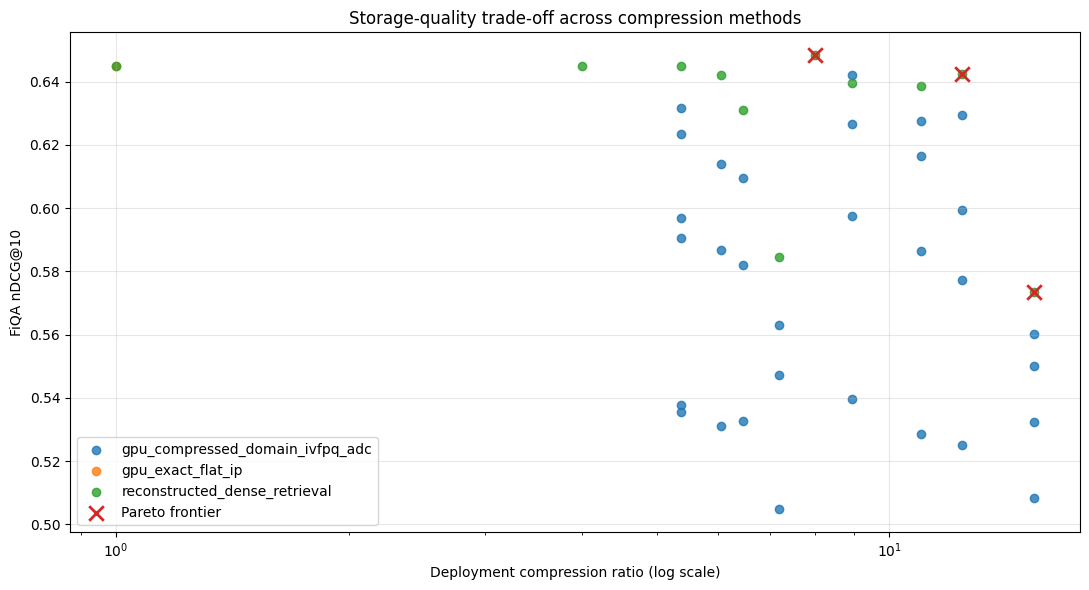

Storage-quality Pareto frontier


,method,retrieval_mode,deployment_compression_ratio,recall_at_10,ndcg_at_10
0,scalar_int4,reconstructed_dense_retrieval,7.999968,0.791667,0.648413
1,pq_m48_k256,reconstructed_dense_retrieval,12.400449,0.773333,0.642287
2,pq_m24_k256,reconstructed_dense_retrieval,15.380535,0.719500,0.573569


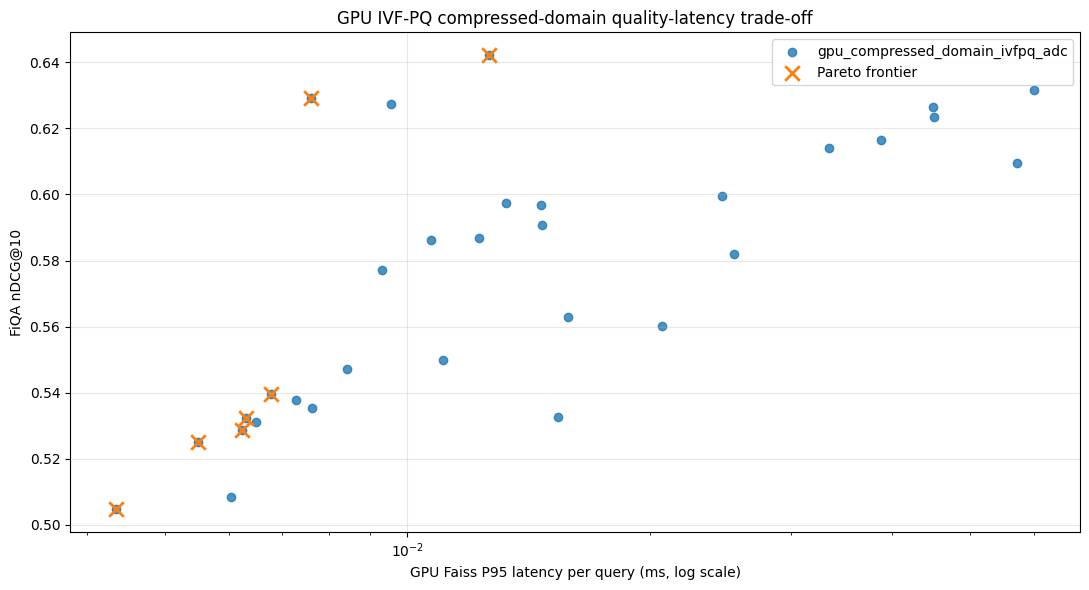

GPU IVF-PQ latency-quality Pareto frontier


,method,nprobe,p50_latency_ms,p95_latency_ms,queries_per_second,recall_at_10,ndcg_at_10
0,gpu_ivfpq_adc_m96_b8_nlist1_np1,1.0,0.012311,0.012635,81459.992160,0.784333,0.642194
1,gpu_ivfpq_adc_m48_b8_nlist1_np1,1.0,0.007272,0.007600,136866.484590,0.770167,0.629307
2,gpu_ivfpq_adc_m96_b8_nlist256_np4,4.0,0.006660,0.006774,151171.490470,0.649444,0.539778
3,gpu_ivfpq_adc_m24_b8_nlist1_np1,1.0,0.006170,0.006313,161757.904023,0.678667,0.532248
4,gpu_ivfpq_adc_m64_b8_nlist256_np4,4.0,0.005962,0.006228,167263.195178,0.642778,0.528626
5,gpu_ivfpq_adc_m48_b8_nlist256_np4,4.0,0.005175,0.005495,191860.613260,0.633778,0.525125
6,gpu_opq_ivfpq_adc_m24_b8_nlist256_np4,4.0,0.003963,0.004348,247455.127019,0.642778,0.504716


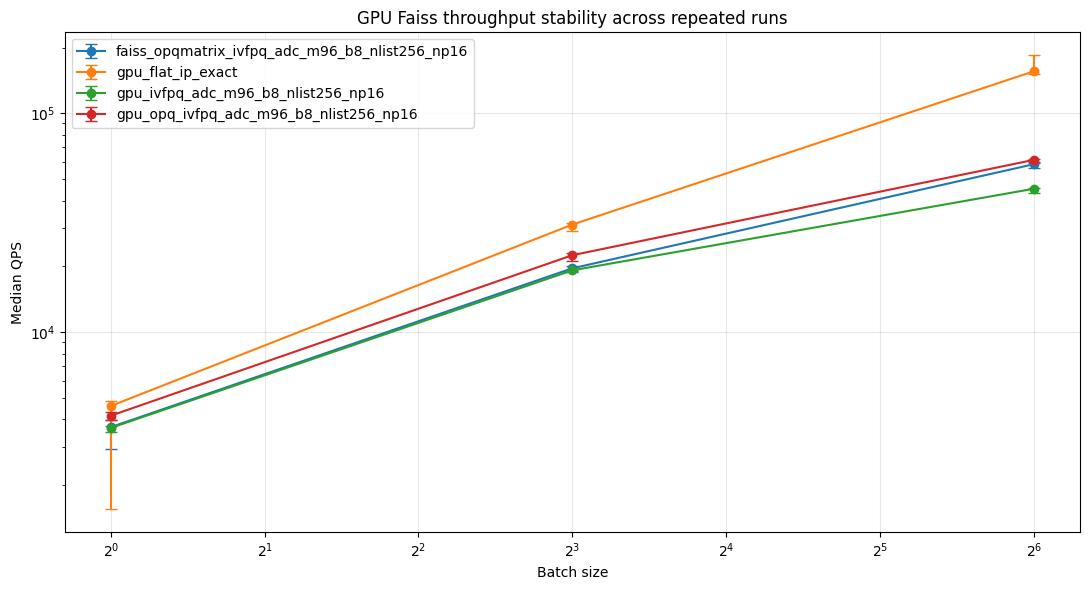

Saved README figures:
scifact_rag_results/readme_artifacts/storage_quality_tradeoff.png
scifact_rag_results/readme_artifacts/gpu_latency_quality_tradeoff.png
scifact_rag_results/readme_artifacts/throughput_stability.png


In [13]:
# 11. Core figures: storage-quality, GPU latency-quality, and serving stability
# Keep these three figures for README/reporting. Detailed raw tables are
# exported below.

from pathlib import Path

ARTIFACT_DIR = Path("scifact_bge_small_rag_results/readme_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def pareto_frontier_higher_is_better(df, x_col, y_col):
    """
    Return rows not dominated when larger values are better on both axes.
    """
    values = df[[x_col, y_col]].to_numpy(dtype=float)
    keep = np.ones(len(df), dtype=bool)

    for i, (x_i, y_i) in enumerate(values):
        dominated = (
            (values[:, 0] >= x_i)
            & (values[:, 1] >= y_i)
            & (
                (values[:, 0] > x_i)
                | (values[:, 1] > y_i)
            )
        )

        keep[i] = not np.any(dominated)

    return (
        df.loc[keep]
        .sort_values(x_col)
        .reset_index(drop=True)
    )


# ============================================================
# A. Storage-quality trade-off
#
# This figure includes both reconstructed dense retrieval and
# compressed-domain IVF-PQ ADC. They are displayed with separate
# retrieval_mode labels and should not be treated as identical
# serving pipelines.
# ============================================================

storage_quality_df = results_df.dropna(
    subset=[
        "deployment_compression_ratio",
        "ndcg_at_10",
    ]
).copy()

storage_quality_df = storage_quality_df[
    (storage_quality_df["deployment_compression_ratio"] > 0)
    & (storage_quality_df["ndcg_at_10"] >= 0)
].copy()

storage_quality_df["retrieval_mode"] = (
    storage_quality_df["retrieval_mode"]
    .fillna("reconstructed_dense_retrieval")
)

storage_frontier_df = pareto_frontier_higher_is_better(
    storage_quality_df,
    "deployment_compression_ratio",
    "ndcg_at_10",
)

plt.figure(figsize=(11, 6))

for mode, part in storage_quality_df.groupby("retrieval_mode"):
    plt.scatter(
        part["deployment_compression_ratio"],
        part["ndcg_at_10"],
        label=str(mode),
        alpha=0.8,
    )

plt.scatter(
    storage_frontier_df["deployment_compression_ratio"],
    storage_frontier_df["ndcg_at_10"],
    marker="x",
    s=110,
    linewidths=2,
    label="Pareto frontier",
)

plt.xscale("log")
plt.xlabel("Deployment compression ratio (log scale)")
plt.ylabel("FiQA nDCG@10")
plt.title("Storage-quality trade-off across compression methods")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

storage_fig_path = ARTIFACT_DIR / "storage_quality_tradeoff.png"
plt.savefig(
    storage_fig_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print("Storage-quality Pareto frontier")

display(
    storage_frontier_df[
        [
            "method",
            "retrieval_mode",
            "deployment_compression_ratio",
            "recall_at_10",
            "ndcg_at_10",
        ]
    ]
)


# ============================================================
# B. GPU IVF-PQ compressed-domain latency-quality trade-off
#
# Exact FlatIP is deliberately excluded. This chart compares only
# compressed-domain IVF-PQ / OPQ-IVF-PQ methods.
# Lower P95 latency is better, so it is negated only for
# Pareto-frontier computation.
# ============================================================

adc_df = faiss_results_df[
    faiss_results_df["retrieval_mode"]
    == "gpu_compressed_domain_ivfpq_adc"
].dropna(
    subset=[
        "p95_latency_ms",
        "ndcg_at_10",
        "queries_per_second",
    ]
).copy()

adc_df = adc_df[
    (adc_df["p95_latency_ms"] > 0)
    & (adc_df["queries_per_second"] > 0)
    & (adc_df["ndcg_at_10"] >= 0)
].copy()

adc_df["neg_p95_latency_ms"] = -adc_df["p95_latency_ms"]

latency_frontier_df = (
    pareto_frontier_higher_is_better(
        adc_df,
        "neg_p95_latency_ms",
        "ndcg_at_10",
    )
    .drop(columns="neg_p95_latency_ms")
)

plt.figure(figsize=(11, 6))

for mode, part in adc_df.groupby("retrieval_mode"):
    plt.scatter(
        part["p95_latency_ms"],
        part["ndcg_at_10"],
        label=str(mode),
        alpha=0.8,
    )

plt.scatter(
    latency_frontier_df["p95_latency_ms"],
    latency_frontier_df["ndcg_at_10"],
    marker="x",
    s=110,
    linewidths=2,
    label="Pareto frontier",
)

plt.xscale("log")
plt.xlabel("GPU Faiss P95 latency per query (ms, log scale)")
plt.ylabel("FiQA nDCG@10")
plt.title("GPU IVF-PQ compressed-domain quality-latency trade-off")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

latency_fig_path = ARTIFACT_DIR / "gpu_latency_quality_tradeoff.png"
plt.savefig(
    latency_fig_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print("GPU IVF-PQ latency-quality Pareto frontier")

display(
    latency_frontier_df[
        [
            "method",
            "nprobe",
            "p50_latency_ms",
            "p95_latency_ms",
            "queries_per_second",
            "recall_at_10",
            "ndcg_at_10",
        ]
    ]
)


# ============================================================
# C. Repeated-run throughput stability
#
# The stability benchmark already captures batch-size effects and
# run-to-run variation, so no separate one-shot throughput plot
# is exported.
# ============================================================

if stability_df.empty:
    raise RuntimeError(
        "stability_df is empty. Run Cell 10 before generating figures."
    )

plt.figure(figsize=(11, 6))

for method, part in stability_df.groupby("method"):
    part = part.sort_values("batch_size")

    median_qps = part["qps_median"]

    lower = np.maximum(
        median_qps - part["qps_p10"],
        0,
    )

    upper = np.maximum(
        part["qps_p90"] - median_qps,
        0,
    )

    plt.errorbar(
        part["batch_size"],
        median_qps,
        yerr=[lower, upper],
        marker="o",
        capsize=4,
        label=method,
    )

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Batch size")
plt.ylabel("Median QPS")
plt.title("GPU Faiss throughput stability across repeated runs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

throughput_fig_path = ARTIFACT_DIR / "throughput_stability.png"
plt.savefig(
    throughput_fig_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print("Saved README figures:")
print(storage_fig_path)
print(latency_fig_path)
print(throughput_fig_path)

In [14]:
# 12. Optional qualitative retrieval inspection
# Run show_retrieval(...) manually when inspecting a specific query/method pair.

def _print_retrieval_results(query_position, method, ranked_indices):
    """Print retrieved documents together with FiQA qrels labels."""
    qid = query_ids[query_position]

    print("Method:", method)
    print("Query ID:", qid)
    print("Query:", query_texts[query_position])
    print("Judged relevant document IDs:", list(qrels[qid].keys())[:10])

    for rank, idx in enumerate(ranked_indices, start=1):
        doc_id = doc_ids[idx]
        row = corpus_rows[idx]
        relevance = qrels[qid].get(doc_id, 0)

        print(f"\n[{rank}] doc_id={doc_id}, qrels_score={relevance}")
        print("Title:", (row.get("title") or "(no title)")[:180])
        print("Text :", (row.get("text") or "")[:500].replace("\n", " "))


def show_retrieval(query_position, method="float32_original", top_k=5):
    """Inspect one query for a dense baseline or a GPU Faiss retrieval method."""
    if not 0 <= query_position < N_QUERIES:
        raise IndexError(f"query_position must be between 0 and {N_QUERIES - 1}.")

    if method in faiss_indexes:
        index = faiss_indexes[method]
        nprobe = get_nprobe_from_method(method)
        if nprobe is not None:
            index.nprobe = nprobe

        q = get_queries_for_faiss_method(method)[
            query_position:query_position + 1
        ].contiguous()
        _, ranked = index.search(q, top_k)
        ranked_indices = [int(i) for i in to_numpy_ids(ranked)[0] if int(i) >= 0]

    elif method in compressed_doc_embeddings:
        q = X_queries[query_position:query_position + 1].contiguous().float()
        rankings, _ = gpu_topk(q, compressed_doc_embeddings[method], top_k, batch_size=1)
        ranked_indices = [
            int(i) for i in rankings[0].detach().cpu().tolist() if int(i) >= 0
        ]
    else:
        known = sorted(set(compressed_doc_embeddings) | set(faiss_indexes))
        raise ValueError(f"Unknown method: {method}. Available methods: {known}")

    _print_retrieval_results(query_position, method, ranked_indices)
    return ranked_indices


# Example (run manually):
# show_retrieval(0, "gpu_opq_ivfpq_adc_m96_b8_nlist256_np16", top_k=5)

In [15]:
# 13. Export benchmark results and reproducibility metadata

results_df.to_csv(
    RESULT_DIR / "fiqa_rag_compression_results.csv",
    index=False,
    encoding="utf-8-sig",
)

faiss_results_df.to_csv(
    RESULT_DIR / "scifact_gpu_ivfpq_adc_results.csv",
    index=False,
    encoding="utf-8-sig",
)

storage_frontier_df.to_csv(
    RESULT_DIR / "scifact_storage_quality_pareto_frontier.csv",
    index=False,
    encoding="utf-8-sig",
)

latency_frontier_df.to_csv(
    RESULT_DIR / "scifact_gpu_latency_quality_pareto_frontier.csv",
    index=False,
    encoding="utf-8-sig",
)

stability_df.to_csv(
    RESULT_DIR / "scifact_gpu_throughput_stability.csv",
    index=False,
    encoding="utf-8-sig",
)


metadata = {
    "dataset": DATASET_DISPLAY_NAME,
    "corpus_documents": int(N_DOCS),
    "test_queries": int(N_QUERIES),
    "embedding_model": EMBEDDING_MODEL,
    "embedding_dimension": int(D),
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0),
    "retrieval_metrics": [
        "Recall@5",
        "Recall@10",
        "MRR@10",
        "nDCG@10",
    ],
    "storage_rule": (
        "Document embeddings only; deployment bytes include PQ codes, "
        "codebooks/scales, serialized Faiss index overhead, and required "
        "learned transforms."
    ),
    "retrieval_modes": [
        "dense retrieval over reconstructed compressed document vectors",
        "GPU exact Float32 inner-product retrieval",
        "Faiss GPU compressed-domain IVF-PQ ADC",
    ],
    "faiss": {
        "backend": "faiss-gpu-cu12 / CUDA",
        "gpu_training": True,
        "nlist": int(FAISS_NLIST),
        "nprobe_values": [
            int(value)
            for value in FAISS_NPROBE_VALUES
        ],
        "pq_settings": FAISS_PQ_SETTINGS,
        "pytorch_opq_settings": FAISS_OPQ_SETTINGS,
        "native_opqmatrix_settings": FAISS_NATIVE_OPQ_SETTINGS,
        "native_opqmatrix_training": {
            "train_points": int(FAISS_NATIVE_OPQ_TRAIN_POINTS),
            "niter": int(FAISS_NATIVE_OPQ_NITER),
            "niter_pq": int(FAISS_NATIVE_OPQ_NITER_PQ),
        },
    },
    "serving_stability": {
        "runs_per_configuration": int(STABILITY_RUNS),
        "batch_sizes": [
            int(value)
            for value in STABILITY_BATCH_SIZES
        ],
        "reported_statistics": [
            "median",
            "p10",
            "p90",
        ],
        "timing_contract": (
            "Retrieval metrics use all queries. Latency and QPS are computed "
            "from synchronized full-size batches only; incomplete final "
            "batches are excluded from timing."
        ),
        "timing_fields": {
            "timed_query_count": (
                "Number of queries included in latency and QPS calculation."
            ),
            "tail_queries_excluded": (
                "Queries still used for retrieval metrics but excluded from "
                "latency and QPS because they form an incomplete final batch."
            ),
        },
    },
}

(RESULT_DIR / "scifact_rag_metadata.json").write_text(
    json.dumps(
        metadata,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)


research_notes = """# SciFact RAG Compression Benchmark Notes

## Evaluation protocol

- SciFact is evaluated as query-to-document retrieval with BEIR qrels.
- Retrieval quality is reported with Recall@5, Recall@10, MRR@10, and nDCG@10.
- Document embeddings are compressed; query embeddings remain Float32 unless transformed by the corresponding OPQ rotation.
- Scalar/custom PQ rows use reconstructed-document dense retrieval.
- Faiss IVF-PQ rows use GPU-side training, index construction, and compressed-domain ADC search.
- Native Faiss OPQMatrix is trained on CPU, then applied before the same GPU IVF-PQ ADC path.
- External PyTorch or Faiss OPQ transforms are included in deployment storage accounting.

## Storage accounting

- Analytical deployment compression includes document payload, codebooks/scales, and required learned transforms.
- Serialized Faiss deployment compression additionally reflects serialized index overhead.
- Analytical and serialized deployment compression should be reported separately.

## Timing contract

- GPU latency uses synchronized Faiss batch measurements.
- Retrieval metrics use all available queries.
- Latency and QPS use only full-size batches.
- Incomplete tail batches are excluded from latency/QPS to avoid distorting per-query P95 values.
- Timing output records `timed_query_count` and `tail_queries_excluded`.
- GPU Faiss search-only latency/QPS must not be compared directly with end-to-end API benchmark throughput.

## Interpretation

- Storage-quality, GPU latency-quality, and repeated-run throughput figures represent different trade-offs.
- Exact GPU FlatIP is a dense retrieval reference and is excluded from the compressed-domain IVF-PQ latency-quality Pareto frontier.
- Repeated-run stability statistics are reported as median, P10, and P90 across independent benchmark runs.
"""

(RESULT_DIR / "research_notes.md").write_text(
    research_notes,
    encoding="utf-8",
)

print("Saved benchmark outputs in:", RESULT_DIR.resolve())

Saved benchmark outputs in: /content/scifact_rag_results


## What this notebook produces

This notebook evaluates four distinct layers without mixing their conclusions:

1. **SciFact reconstructed-vector quality** — scalar quantization, custom GPU PQ, and PyTorch-learned OPQ-PQ.
2. **Faiss GPU compressed-domain retrieval** — GPU `IVF-PQ` ADC with GPU-side training, index construction, and synchronized search timing.
3. **OPQ implementation baseline** — PyTorch-learned OPQ versus native Faiss `OPQMatrix`, each followed by the same GPU IVF-PQ ADC path.
4. **Serving stability** — five repeated runs for representative Faiss configurations at batch sizes 1, 8, and 64.

The retained figures are intentionally limited to:
- storage compression versus retrieval quality,
- GPU latency versus retrieval quality,
- repeated-run serving throughput stability.

The notebook exports the result tables, Pareto frontiers, figures, metadata, and a serialized service index for the repository API workflow.

In [16]:
# 14. Export README-ready benchmark tables
# Keep headline results concise and use the same timing contract as Cells 9-13.

README_ARTIFACT_DIR = RESULT_DIR / "readme_artifacts"
README_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

README_METHODS = [
    "gpu_flat_ip_exact",
    "gpu_ivfpq_adc_m96_b8_nlist256_np16",
    "gpu_opq_ivfpq_adc_m96_b8_nlist256_np16",
    "faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16",
]

main_results_df = (
    faiss_results_df[
        faiss_results_df["method"].isin(README_METHODS)
    ]
    .copy()
)

# Preserve the intended README comparison order.
method_order = {
    method: position
    for position, method in enumerate(README_METHODS)
}

main_results_df["_method_order"] = (
    main_results_df["method"].map(method_order)
)

main_results_df = (
    main_results_df
    .sort_values("_method_order")
    .drop(columns="_method_order")
    .reset_index(drop=True)
)

required_methods = set(README_METHODS)
available_methods = set(main_results_df["method"])

missing_methods = sorted(required_methods - available_methods)

if missing_methods:
    raise RuntimeError(
        "Missing README benchmark methods. "
        "Run Cells 9 and 9.1 before Cell 14. "
        f"Missing: {missing_methods}"
    )

main_results_df = main_results_df[
    [
        "method",
        "retrieval_mode",
        "nprobe",
        "deployment_compression_ratio",
        "serialized_faiss_total_deployment_compression_ratio",
        "recall_at_10",
        "mrr_at_10",
        "ndcg_at_10",
        "timed_query_count",
        "tail_queries_excluded_from_latency",
        "p50_latency_ms",
        "p95_latency_ms",
        "queries_per_second",
    ]
].copy()

main_results_df = main_results_df.rename(
    columns={
        "method": "Method",
        "retrieval_mode": "Retrieval mode",
        "nprobe": "nprobe",
        "deployment_compression_ratio": (
            "Analytical deployment compression"
        ),
        "serialized_faiss_total_deployment_compression_ratio": (
            "Serialized deployment compression"
        ),
        "recall_at_10": "Recall@10",
        "mrr_at_10": "MRR@10",
        "ndcg_at_10": "nDCG@10",
        "timed_query_count": "Timed queries",
        "tail_queries_excluded_from_latency": (
            "Tail queries excluded from timing"
        ),
        "p50_latency_ms": "P50 latency / query (ms)",
        "p95_latency_ms": "P95 latency / query (ms)",
        "queries_per_second": "QPS",
    }
)

main_results_display_df = main_results_df.copy()

numeric_rounding = {
    "nprobe": 0,
    "Analytical deployment compression": 2,
    "Serialized deployment compression": 2,
    "Recall@10": 4,
    "MRR@10": 4,
    "nDCG@10": 4,
    "Timed queries": 0,
    "Tail queries excluded from timing": 0,
    "P50 latency / query (ms)": 4,
    "P95 latency / query (ms)": 4,
    "QPS": 1,
}

main_results_display_df = main_results_display_df.round(
    numeric_rounding
)

main_results_csv_path = (
    README_ARTIFACT_DIR / "readme_main_results.csv"
)

main_results_md_path = (
    README_ARTIFACT_DIR / "readme_main_results.md"
)

main_results_display_df.to_csv(
    main_results_csv_path,
    index=False,
    encoding="utf-8-sig",
)

main_results_md_path.write_text(
    main_results_display_df.to_markdown(index=False),
    encoding="utf-8",
)


# ------------------------------------------------------------
# README stability table
# ------------------------------------------------------------

README_STABILITY_METHODS = [
    "gpu_flat_ip_exact",
    "gpu_ivfpq_adc_m96_b8_nlist256_np16",
    "gpu_opq_ivfpq_adc_m96_b8_nlist256_np16",
    "faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16",
]

stability_readme_df = (
    stability_df[
        stability_df["method"].isin(README_STABILITY_METHODS)
    ]
    .copy()
)

stability_readme_df["_method_order"] = (
    stability_readme_df["method"].map(method_order)
)

stability_readme_df = (
    stability_readme_df
    .sort_values(["batch_size", "_method_order"])
    .drop(columns="_method_order")
    .reset_index(drop=True)
)

if stability_readme_df.empty:
    raise RuntimeError(
        "README stability table is empty. Run Cell 10 first."
    )

stability_readme_df = stability_readme_df[
    [
        "method",
        "batch_size",
        "nprobe",
        "runs",
        "timed_query_count",
        "tail_queries_excluded",
        "p50_latency_ms_median",
        "p95_latency_ms_median",
        "qps_median",
        "qps_p10",
        "qps_p90",
    ]
].copy()

stability_readme_df = stability_readme_df.rename(
    columns={
        "method": "Method",
        "batch_size": "Batch size",
        "nprobe": "nprobe",
        "runs": "Runs",
        "timed_query_count": "Timed queries",
        "tail_queries_excluded": (
            "Tail queries excluded from timing"
        ),
        "p50_latency_ms_median": "Median P50 latency (ms)",
        "p95_latency_ms_median": "Median P95 latency (ms)",
        "qps_median": "Median QPS",
        "qps_p10": "QPS P10",
        "qps_p90": "QPS P90",
    }
)

stability_readme_display_df = stability_readme_df.round(
    {
        "nprobe": 0,
        "Runs": 0,
        "Timed queries": 0,
        "Tail queries excluded from timing": 0,
        "Median P50 latency (ms)": 4,
        "Median P95 latency (ms)": 4,
        "Median QPS": 1,
        "QPS P10": 1,
        "QPS P90": 1,
    }
)

stability_csv_path = (
    README_ARTIFACT_DIR / "readme_stability_results.csv"
)

stability_md_path = (
    README_ARTIFACT_DIR / "readme_stability_results.md"
)

stability_readme_display_df.to_csv(
    stability_csv_path,
    index=False,
    encoding="utf-8-sig",
)

stability_md_path.write_text(
    stability_readme_display_df.to_markdown(index=False),
    encoding="utf-8",
)


# ------------------------------------------------------------
# README text snippets
# ------------------------------------------------------------

headline_row = main_results_df[
    main_results_df["Method"]
    == "gpu_opq_ivfpq_adc_m96_b8_nlist256_np16"
].iloc[0]

faiss_native_row = main_results_df[
    main_results_df["Method"]
    == "faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16"
].iloc[0]

headline_summary = f"""## Headline result

At `M=96`, `8-bit PQ`, `nlist={FAISS_NLIST}`, and `nprobe=16`, the
PyTorch OPQ + GPU IVF-PQ ADC configuration achieved:

- **{headline_row["Analytical deployment compression"]:.2f}× analytical deployment compression**
- **{headline_row["Serialized deployment compression"]:.2f}× serialized deployment compression**
- **Recall@10 = {headline_row["Recall@10"]:.4f}**
- **nDCG@10 = {headline_row["nDCG@10"]:.4f}**
- **P95 latency = {headline_row["P95 latency / query (ms)"]:.4f} ms/query**
- **QPS = {headline_row["QPS"]:.1f}**

The native Faiss `OPQMatrix` baseline under the same IVF-PQ configuration
achieved Recall@10 = {faiss_native_row["Recall@10"]:.4f} and
nDCG@10 = {faiss_native_row["nDCG@10"]:.4f}, showing comparable quality.

> Timing contract: retrieval metrics use all {N_QUERIES} queries. Latency and
> QPS use synchronized full-size batches only. For batch size 64, the final
> incomplete tail batch is excluded from timing.
"""

headline_path = (
    README_ARTIFACT_DIR / "readme_headline_summary.md"
)

headline_path.write_text(
    headline_summary,
    encoding="utf-8",
)


# ------------------------------------------------------------
# Console preview
# ------------------------------------------------------------

print("README main benchmark table:")
display(main_results_display_df)

print("\nREADME repeated-run stability table:")
display(stability_readme_display_df)

print("\nSaved README-ready artifacts:")
print(main_results_csv_path)
print(main_results_md_path)
print(stability_csv_path)
print(stability_md_path)
print(headline_path)

README main benchmark table:


,Method,Retrieval mode,nprobe,Analytical deployment compression,Serialized deployment compression,Recall@10,MRR@10,nDCG@10,Timed queries,Tail queries excluded from timing,P50 latency / query (ms),P95 latency / query (ms),QPS
0,gpu_flat_ip_exact,gpu_exact_flat_ip,NaN,1.00,1.00,0.7833,0.6047,0.6451,256,44,0.0057,0.0077,160649.4
1,gpu_ivfpq_adc_m96_b8_nlist256_np16,gpu_compressed_domain_ivfpq_adc,16.0,8.94,6.00,0.7206,0.5630,0.5975,256,44,0.0132,0.0133,75808.1
2,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,gpu_compressed_domain_ivfpq_adc,16.0,5.38,4.15,0.7056,0.5576,0.5906,256,44,0.0139,0.0147,71159.7
3,faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16,gpu_compressed_domain_ivfpq_adc,16.0,5.38,4.15,0.7156,0.5616,0.5969,256,44,0.0145,0.0147,69113.5



README repeated-run stability table:


,Method,Batch size,nprobe,Runs,Timed queries,Tail queries excluded from timing,Median P50 latency (ms),Median P95 latency (ms),Median QPS,QPS P10,QPS P90
0,gpu_flat_ip_exact,1,NaN,5,300,0,0.2076,0.2551,4607.2,1551.7,4839.1
1,gpu_ivfpq_adc_m96_b8_nlist256_np16,1,16.0,5,300,0,0.2633,0.3190,3658.5,3509.0,3745.7
2,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,1,16.0,5,300,0,0.2311,0.3242,4159.7,3977.6,4312.7
3,faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16,1,16.0,5,300,0,0.2383,0.3763,3687.6,2939.3,3961.0
4,gpu_flat_ip_exact,8,NaN,5,296,4,0.0319,0.0354,31072.7,29015.1,31561.2
5,gpu_ivfpq_adc_m96_b8_nlist256_np16,8,16.0,5,296,4,0.0519,0.0553,19196.6,18976.2,19332.1
6,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,8,16.0,5,296,4,0.0442,0.0472,22506.8,21213.6,23149.0
7,faiss_opqmatrix_ivfpq_adc_m96_b8_nlist256_np16,8,16.0,5,296,4,0.0509,0.0561,19608.6,18832.6,20167.5
8,gpu_flat_ip_exact,64,NaN,5,256,44,0.0062,0.0071,155872.8,150883.4,184862.1
9,gpu_ivfpq_adc_m96_b8_nlist256_np16,64,16.0,5,256,44,0.0220,0.0226,45285.0,43096.5,45504.9



Saved README-ready artifacts:
scifact_rag_results/readme_artifacts/readme_main_results.csv
scifact_rag_results/readme_artifacts/readme_main_results.md
scifact_rag_results/readme_artifacts/readme_stability_results.csv
scifact_rag_results/readme_artifacts/readme_stability_results.md
scifact_rag_results/readme_artifacts/readme_headline_summary.md


In [17]:
# 15. Cross-dataset study note
#
# This notebook evaluates SciFact as a second BEIR dataset.
# It intentionally does NOT replace the deployed FiQA FastAPI artifact.
#
# Keep the service artifact in the main repository tied to FiQA, where the
# local API, Docker metadata regeneration, and end-to-end tests are verified.
#
# After this notebook completes, compare:
#   fiqa_bge_small_rag_results/readme_artifacts/readme_main_results.csv
#   scifact_bge_small_rag_results/readme_artifacts/readme_main_results.csv
#
# The comparison should report the same embedding model, IVF configuration,
# timing contract, and evaluation metrics across both datasets.

print("SciFact benchmark complete.")
print("Results directory:", RESULT_DIR.resolve())
print(
    "Next: compare SciFact outputs with FiQA; do not overwrite the deployed "
    "FiQA OPQ-IVF-PQ service artifact."
)


SciFact benchmark complete.
Results directory: /content/scifact_rag_results
Next: compare SciFact outputs with FiQA; do not overwrite the deployed FiQA OPQ-IVF-PQ service artifact.
